# Hermite-Gauss modes
Hermite–Gauss (HG) modes are a family of solutions to the paraxial wave equation, which describes the propagation of laser beams under the paraxial approximation. These modes represent the transverse field distributions of light in optical systems.

The simplest member of this family is the fundamental Gaussian beam, denoted by $TEM_{00}$. Higher-order modes are obtained by modulating the Gaussian profile with Hermite polynomials along the x and y directions.

HG modes form a complete orthogonal set, meaning that any paraxial beam can be expressed as a superposition of Hermite–Gauss modes.

### Paraxial Wave Equation
For a monochromatic electromagnetic wave propagating primarily along the z-axis, the electric field can be written as
$$E(x,y,z)=U(x,y,z)e^{ikz}$$
where $U(x,y,z)$ is the slowly varying envelope.
Under paraxial approximation, $U(x,y,z)$ satisfies
$$\frac{\partial^2 U}{\partial x^2}+\frac{\partial^2 U}{\partial y^2}+2ik\frac{\partial U}{\partial z}=0$$
Hermite-Gauss modes are exact solutions of this equation.

The electric field distribution of a Hermite–Gauss mode is given by
$$U_{mn} = \frac{1}{w(z)}
H_m\!\left(\frac{\sqrt{2}\,x}{w(z)}\right)
H_n\!\left(\frac{\sqrt{2}\,y}{w(z)}\right)
\exp\!\left[-\frac{x^2+y^2}{w^2(z)}\right]
e^{i\Phi(x,y,z)}$$ 

where 
- $H_m$ and $H_n$ are Hermite polynomials,
- $m$ and $n$ are mode indices,
- $w(z)$ is the beam radius,
- $\Phi(x,y,z)$ is the Gouy phase which contains the propagation and phase terms.

Mode indices m determines the structure along the x-direction and n determines the structure along the y-direction.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hermite

def hermite_gauss_mode(x, y, m, n, w0):
    """Calculate the Hermite-Gauss mode field distribution."""
    Hm = hermite(m)(np.sqrt(2) * x / w0)
    Hn = hermite(n)(np.sqrt(2) * y / w0)
    return Hm * Hn * np.exp(-(x**2 + y**2) / w0**2)

# Parameters
w0 = 1.0  # Beam waist
x = np.linspace(-3*w0, 3*w0, 100)
y = np.linspace(-3*w0, 3*w0, 100)
X, Y = np.meshgrid(x, y)

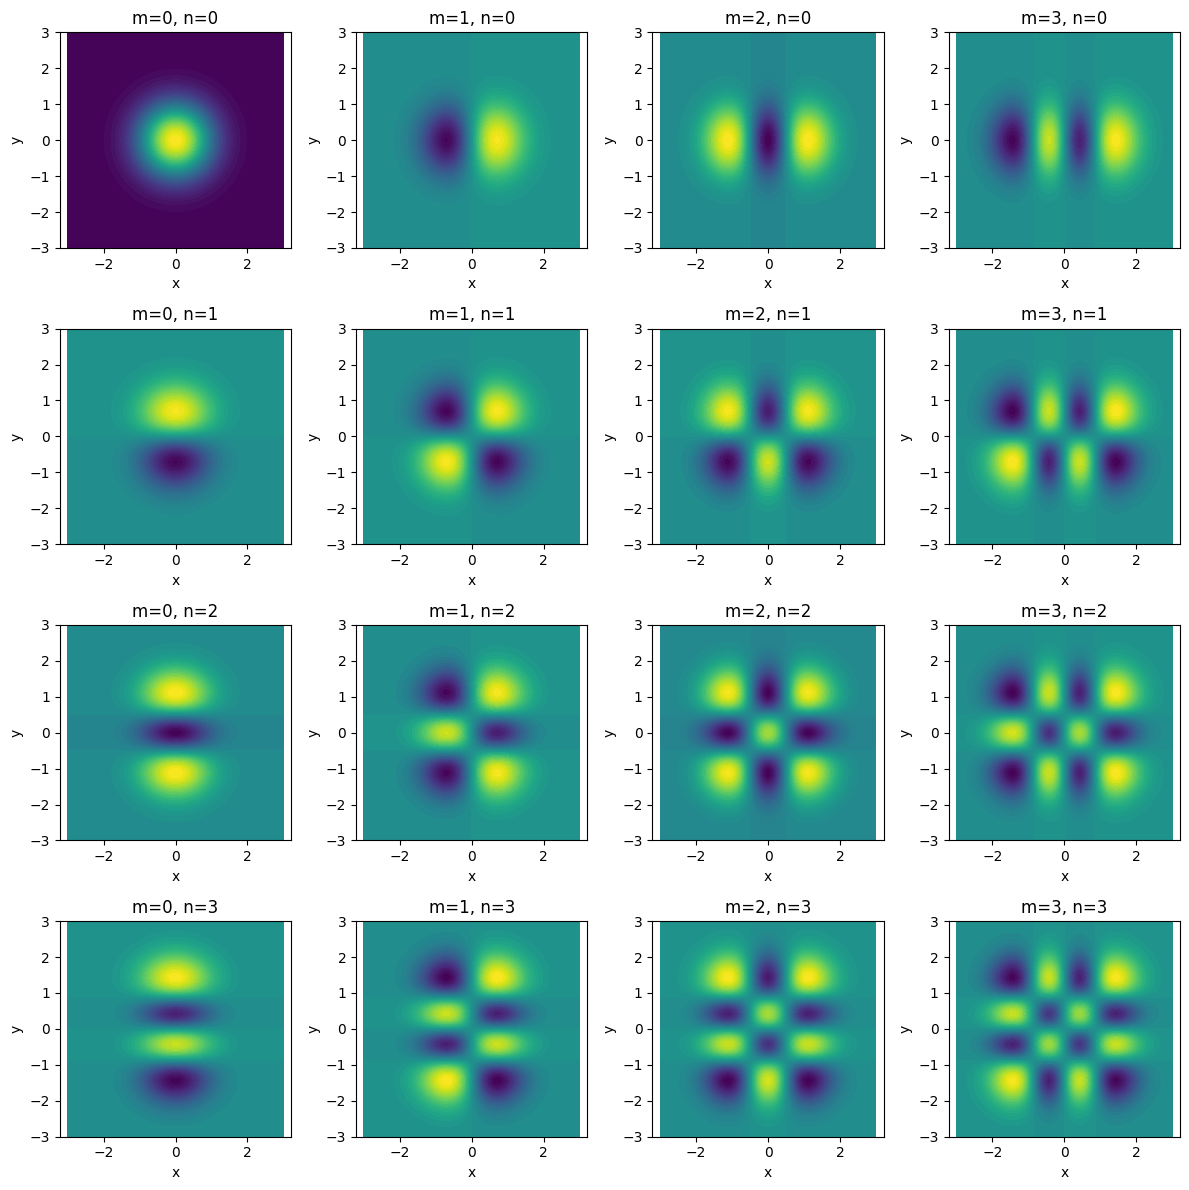

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
modes = [(0, 0), (1, 0), (2, 0), (3, 0),
         (0, 1), (1, 1), (2, 1), (3, 1),
         (0, 2), (1, 2), (2, 2), (3, 2),
         (0, 3), (1, 3), (2, 3), (3, 3)]

for ax, (m, n) in zip(axes.flatten(), modes):
    field = hermite_gauss_mode(X, Y, m, n, w0)
    ax.contourf(X, Y, field, levels=50, cmap='viridis')
    ax.set_title(f'm={m}, n={n}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal')
plt.tight_layout()
plt.show()
